## About {-}
A short exercise that uses the Python equivalent to Matlab `eigs()` for computing the first k eigenvalues and eigenvectors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.sparse.linalg import eigs
from numpy.linalg import norm
import sys
import os
import time

sys.path.append("/home/hana/Documents/dalhousie/training/CREATE/Data_Module/codes/eof-analysis")
from eofs import eofs

In [2]:
# ==============================
# Basic EOF that captures spatial distribution of temporal variance
# ==============================

# Load data
mat = loadmat("../bbm_tidecrittry.mat")
data = mat["B2s"]  # adjust key if needed

num_modes = 170
M, N = data.shape

# the data set is 2048 points in space by 600 points in time
print('Size:', (M, N))

# Remove mean (along time dimension, MATLAB dim=2)
data_noav = data - data.mean(axis=1, keepdims=True)

# Coordinates (bbm_tidecrittry case)
myx = np.arange(0.5, 2047.5 + 1) / 4096
mytime = np.arange(0, 600)

# coeff - Time coefficients
# lambda_vals - Eigenvalues (unnormalized, descending order)
# u - Spatial EOFs (eigenvectors as columns)
# cumul_approx - Cumulative approximations using 1..k modes
start = time.time()
lambda_vals, u, coeff, cumul_approx = eofs(data_noav, num_modes)
print(time.time() - start, 'seconds')

Size: (2048, 600)
1.2547190189361572 seconds


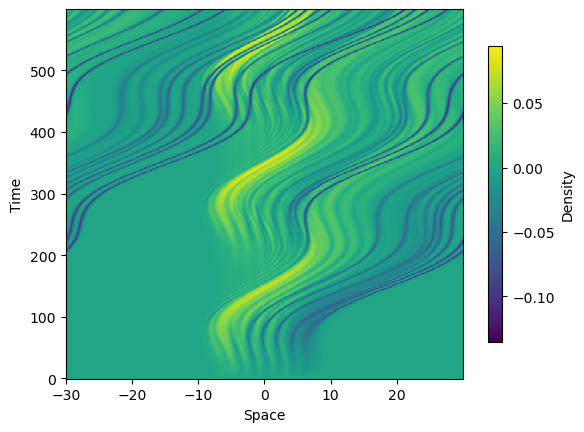

In [3]:
c1 = plt.pcolormesh(
    mat['x'],
    np.arange(N),
    data.T,
    shading='nearest'
)
plt.colorbar(c1, label='Density', shrink=0.8)
plt.xlabel('Space')
plt.ylabel('Time')
plt.show()

In [4]:
# Compute covariance matrix to use eigs
# eigs requires a square input matrix
# Each row of m represents a variable, and each column a single observation of all those variables
for kk in [5, 150]:
    start = time.time()
    cov_mtx = np.cov(data_noav)
    lambda_vals, u = eigs(cov_mtx, k=kk)
    print(kk, time.time() - start, 'seconds')

5 0.5000536441802979 seconds
150 1.936821460723877 seconds


Using `eigs()` on the covariance matrix to get the first 5 eigenvalues and eigenvectors was a lot faster than using `svds()` in the `eofs()` function. Finding the first 150 eigenvalues and vectors was slower than `svds()`.

/home/hana/miniconda3/envs/py312/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/hana/miniconda3/envs/py312/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


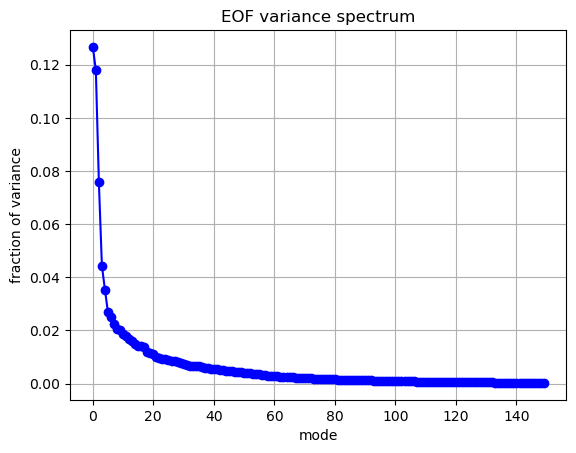

In [5]:
# Eigenvalue spectrum (scree plot)
plt.figure(1)
plt.clf()
plt.plot(lambda_vals / lambda_vals.sum(), "bo-")
plt.xlabel("mode")
plt.ylabel("fraction of variance")
plt.title("EOF variance spectrum")
plt.grid(True)

The scree plot above goes to zero pretty quickly, as expected.